# 04 — ResNet (Transfer Learning)

Pretrained ResNet18 fine-tuned on the same data/split as the baseline CNN, using the same evaluation pipeline for a fair comparison.

## Config & seed

Load the experiment configuration and the reusable data, model, training, and evaluation utilities, set seeds for reproducibility, and resolve output paths for this experiment's checkpoint, metrics, and figures.

In [1]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from src.evaluation.classification import EvaluationResult


def find_repo_root(start: Path) -> Path:
    """Find the repository root by looking for the experiment config.

    Args:
        start: Directory from which to start searching for the repository root.

    Returns:
        Path to the repository root.

    Raises:
        FileNotFoundError: If the repository root cannot be found.
    """
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))

from src.data.config import load_config
from src.data.loaders import build_pretrained_transform, create_dataloaders
from src.evaluation import evaluate_predictions, save_evaluation_outputs
from src.models import build_resnet18, count_trainable_parameters, set_backbone_trainable
from src.training import evaluate, fit, set_seed, train_one_epoch

config: dict = load_config()
SEED: int = config["seed"]
set_seed(SEED)

device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MANIFEST_PATH = REPO_ROOT / "data" / "dataset.csv"
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
CHECKPOINT_PATH = REPO_ROOT / "results" / "checkpoints" / "resnet18.pt"
METRICS_ROOT = REPO_ROOT / "results" / "metrics" / "resnet18"
FIGURES_ROOT = REPO_ROOT / "results" / "figures" / "resnet18"
METRICS_ROOT.mkdir(parents=True, exist_ok=True)
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

Device: cpu


## Data loading

Reuse the same manifest and splits as the baseline CNN, but use the
ImageNet normalization expected by the pretrained ResNet18. No augmentation
is applied so the training setup remains comparable to the baseline model.

In [2]:
loader_config: dict = config["dataloader"]
dataloaders: dict[str, DataLoader] = create_dataloaders(
    manifest=MANIFEST_PATH,
    processed_root=PROCESSED_ROOT,
    batch_size=loader_config["batch_size"],
    num_workers=loader_config["num_workers"],
    seed=SEED,
    pin_memory=device.type == "cuda",
    transform_fn=build_pretrained_transform,
)

print("Dataset sizes:", {split: len(loader.dataset) for split, loader in dataloaders.items()})
sample_batch: dict[str, torch.Tensor] = next(iter(dataloaders["train"]))
print("Image batch shape:", tuple(sample_batch["image"].shape))
print("Label batch shape:", tuple(sample_batch["label"].shape))

Dataset sizes: {'train': 9800, 'val': 2100, 'test': 2100}
Image batch shape: (32, 3, 224, 224)
Label batch shape: (32,)


## Model definition

Load an ImageNet-pretrained ResNet18 and replace its final layer with a
single output logit. The backbone is frozen during the warmup phase, so
only the new classifier head is trained initially.

In [5]:
resnet_config: dict = config["resnet"]
model: nn.Module = build_resnet18(freeze_backbone=True).to(device)
criterion: nn.BCEWithLogitsLoss = nn.BCEWithLogitsLoss()

with torch.inference_mode():
    sample_logits: torch.Tensor = model(sample_batch["image"].to(device))

print(f"Trainable parameters (backbone frozen): {count_trainable_parameters(model):,}")
print("Logit shape:", tuple(sample_logits.shape))
assert sample_logits.shape == sample_batch["label"].shape

Trainable parameters (backbone frozen): 513
Logit shape: (32,)


## Fine-tuning

Train the ResNet18 in two phases. First, train only the new classification head while keeping the pretrained backbone frozen. Then unfreeze the backbone and fine-tune the full model with a lower learning rate. The best model is selected based on validation loss using early stopping.

[warmup] epoch 1/3 | train loss 0.6424, F1 0.6120 | val loss 0.6141, F1 0.6222
[warmup] epoch 2/3 | train loss 0.5919, F1 0.6885 | val loss 0.5954, F1 0.6676
[warmup] epoch 3/3 | train loss 0.5814, F1 0.6952 | val loss 0.6082, F1 0.6120
Trainable parameters (backbone unfrozen): 11,177,025
Epoch 01/20 | train loss 0.5143, F1 0.7349 | val loss 0.4773, F1 0.7729
Epoch 02/20 | train loss 0.3840, F1 0.8328 | val loss 0.4350, F1 0.7917
Epoch 03/20 | train loss 0.3005, F1 0.8788 | val loss 0.4196, F1 0.8096
Epoch 04/20 | train loss 0.2347, F1 0.9113 | val loss 0.4097, F1 0.8193
Epoch 05/20 | train loss 0.1647, F1 0.9488 | val loss 0.4243, F1 0.8173
Epoch 06/20 | train loss 0.1232, F1 0.9620 | val loss 0.4313, F1 0.8274
Epoch 07/20 | train loss 0.0815, F1 0.9820 | val loss 0.4393, F1 0.8243
Epoch 08/20 | train loss 0.0567, F1 0.9893 | val loss 0.4589, F1 0.8209
Epoch 09/20 | train loss 0.0409, F1 0.9929 | val loss 0.4773, F1 0.8313
Early stopping after epoch 9; best epoch was 4.
Best epoch: 4


,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.514262,0.746939,0.771666,0.701429,0.734873,0.828551,0.477347,0.770476,0.764925,0.780952,0.772856,0.852404
1,2,0.383953,0.829592,0.817414,0.848776,0.832799,0.911198,0.434966,0.795238,0.805720,0.778095,0.791667,0.880355
2,3,0.300531,0.877959,0.872786,0.884898,0.878800,0.948716,0.419650,0.811905,0.819512,0.800000,0.809639,0.894295
3,4,0.234717,0.909898,0.897329,0.925714,0.911301,0.971201,0.409701,0.816190,0.805709,0.833333,0.819288,0.900948
4,5,0.164663,0.948265,0.939916,0.957755,0.948752,0.988382,0.424327,0.810952,0.790739,0.845714,0.817303,0.903983
5,6,0.123234,0.961735,0.954591,0.969592,0.962033,0.994015,0.431311,0.817619,0.785287,0.874286,0.827400,0.909665
6,7,0.081521,0.981939,0.980664,0.983265,0.981963,0.998454,0.439336,0.824762,0.826628,0.821905,0.824260,0.911757
7,8,0.056700,0.989286,0.988787,0.989796,0.989291,0.999303,0.458854,0.820000,0.816981,0.824762,0.820853,0.910000
8,9,0.040888,0.992857,0.991453,0.994286,0.992867,0.999836,0.477310,0.824286,0.799472,0.865714,0.831276,0.913878


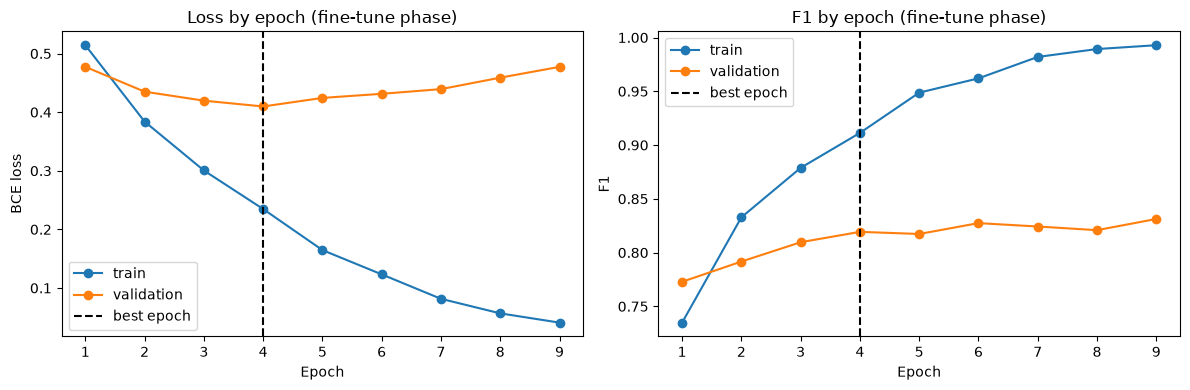

In [6]:
# Phase 1: train only the classifier head with the pretrained backbone frozen.
warmup_optimizer: AdamW = AdamW(
    (parameter for parameter in model.parameters() if parameter.requires_grad),
    lr=resnet_config["warmup_learning_rate"],
    weight_decay=resnet_config["weight_decay"],
)

for epoch in range(1, resnet_config["warmup_epochs"] + 1):
    train_metrics = train_one_epoch(model, dataloaders["train"], criterion, warmup_optimizer, device)
    val_metrics = evaluate(model, dataloaders["val"], criterion, device)
    print(
        f"[warmup] epoch {epoch}/{resnet_config['warmup_epochs']} | "
        f"train loss {train_metrics.loss:.4f}, F1 {train_metrics.f1:.4f} | "
        f"val loss {val_metrics.loss:.4f}, F1 {val_metrics.f1:.4f}"
    )

# Phase 2: unfreeze the backbone and fine-tune the full model.
set_backbone_trainable(model, trainable=True)
print(f"Trainable parameters (backbone unfrozen): {count_trainable_parameters(model):,}")

finetune_optimizer: AdamW  = AdamW(
    model.parameters(),
    lr=resnet_config["finetune_learning_rate"],
    weight_decay=resnet_config["weight_decay"],
)

fit_result = fit(
    model=model,
    train_dataloader=dataloaders["train"],
    val_dataloader=dataloaders["val"],
    criterion=criterion,
    optimizer=finetune_optimizer,
    device=device,
    epochs=resnet_config["finetune_epochs"],
    patience=resnet_config["early_stopping_patience"],
    min_delta=resnet_config["early_stopping_min_delta"],
    checkpoint_path=CHECKPOINT_PATH,
)

history: pd.DataFrame = pd.DataFrame(fit_result.history)
history.to_csv(METRICS_ROOT / "training_history.csv", index=False)
print(f"Best epoch: {fit_result.best_epoch}")
print(f"Best validation loss: {fit_result.best_val_loss:.4f}")
display(history)

# Plot training curves for the fine-tuning phase.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="validation")
axes[0].axvline(fit_result.best_epoch, color="black", linestyle="--", label="best epoch")
axes[0].set_title("Loss by epoch (fine-tune phase)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_f1"], marker="o", label="train")
axes[1].plot(history["epoch"], history["val_f1"], marker="o", label="validation")
axes[1].axvline(fit_result.best_epoch, color="black", linestyle="--", label="best epoch")
axes[1].set_title("F1 by epoch (fine-tune phase)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_ROOT / "training_curves.png", dpi=150)
plt.show()

## Evaluation

Evaluate the fine-tuned ResNet18 once on the previously untouched test split using the same metrics and per-generator breakdown as the baseline CNN. This provides the final held-out performance and shows how consistently the model detects images from different generators.

In [7]:
test_result: EvaluationResult = evaluate_predictions(
    model=model,
    dataloader=dataloaders["test"],
    criterion=criterion,
    device=device,
    threshold=0.5,
)

print("Test metrics:")
display(pd.Series(test_result.metrics.to_dict(), name="value"))
print("Per-generator metrics:")
display(test_result.per_generator)

Test metrics:


loss         0.404653
accuracy     0.823333
precision    0.806685
recall       0.850476
f1           0.828002
roc_auc      0.902329
Name: value, dtype: float64

Per-generator metrics:


,generator,n_ai,n_real,accuracy,precision,recall,f1,roc_auc
0,adm,150,150,0.850000,0.796610,0.940000,0.862385,0.952000
1,biggan,150,150,0.900000,0.852941,0.966667,0.906250,0.954889
2,glide,150,150,0.843333,0.801170,0.913333,0.853583,0.921022
3,midjourney,150,150,0.740000,0.753521,0.713333,0.732877,0.820044
4,sdv1_5,150,150,0.833333,0.812500,0.866667,0.838710,0.909778
5,vqdm,150,150,0.770000,0.809160,0.706667,0.754448,0.855822
6,wukong,150,150,0.826667,0.814103,0.846667,0.830065,0.910489


## Save results

Save the checkpoint, metrics, predictions, and figures for this experiment `results/`.

In [9]:
saved_paths: dict[str, Path] = save_evaluation_outputs(test_result, output_dir=METRICS_ROOT, figures_dir=FIGURES_ROOT)

print("Saved outputs:")
for name, path in saved_paths.items():
    print(f"  {name}: {path.relative_to(REPO_ROOT)}")

Saved outputs:
  metrics: results\metrics\resnet18\test_metrics.json
  predictions: results\metrics\resnet18\test_predictions.csv
  per_generator: results\metrics\resnet18\per_generator_metrics.csv
  confusion_matrix: results\figures\resnet18\confusion_matrix.png
  roc_curve: results\figures\resnet18\roc_curve.png
